Binning is a data transformation technique where you convert continuous numerical data into discrete categories (bins or intervals).

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt

import math

In [2]:
df = pd.read_csv('sample_dataset.csv').iloc[:,0:5].dropna()
df


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
2,19.69,21.25,130.00,1203.0,0.10960
3,11.42,20.38,77.58,386.1,0.14250
8,13.00,21.82,87.50,519.8,0.12730
13,15.85,23.95,103.70,782.7,0.08401
14,13.73,22.61,93.60,578.3,0.11310
...,...,...,...,...,...
549,10.82,24.21,68.89,361.6,0.08192
550,10.86,21.48,68.51,360.5,0.07431
560,14.05,27.15,91.38,600.4,0.09929
564,21.56,22.39,142.00,1479.0,0.11100


In [3]:
binner = KBinsDiscretizer(strategy='uniform',n_bins=5)

In [4]:
binner.fit_transform(df)

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\preprocessing\_discretization.py:239: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


<176x25 sparse matrix of type '<class 'numpy.float64'>'
	with 880 stored elements in Compressed Sparse Row format>

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\preprocessing\_discretization.py:239: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\preprocessing\_discretization.py:239: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


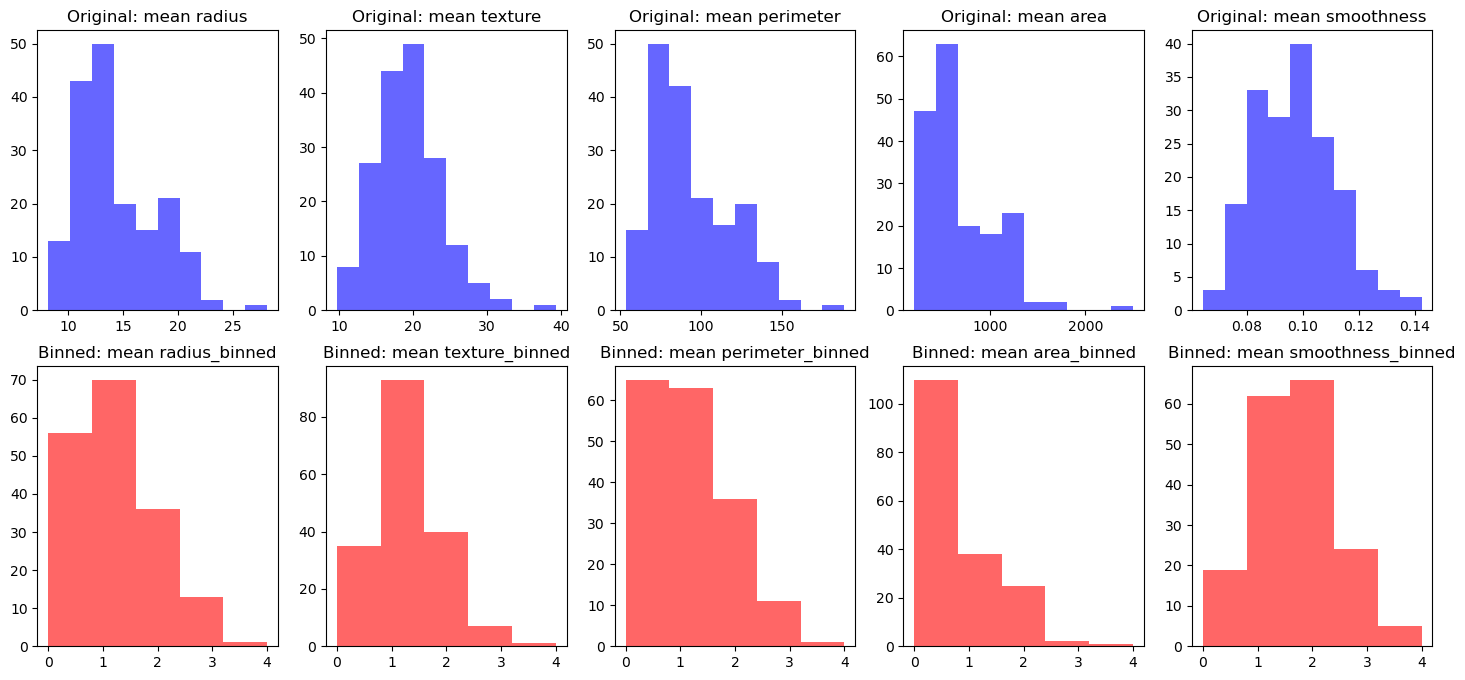

In [24]:
binner = KBinsDiscretizer(strategy='uniform',n_bins=5, encode= 'ordinal')
binner.fit_transform(df)
binned_df = pd.DataFrame(binner.fit_transform(df), columns=[col + '_binned' for col in df.columns])
num_cols = len(df.columns)


num_cols = len(df.columns)
ncols = 5  
nrows = 2  

fig, axes = plt.subplots(nrows, ncols, figsize = (18,8))


for i, col in enumerate(df.columns):
    axes[0, i].hist(df[col], bins=10, color="blue", alpha=0.6)
    axes[0, i].set_title(f"Original: {col}")


for i, col in enumerate(binned_df.columns):
    axes[1, i].hist(binned_df[col], bins=5, color="red", alpha=0.6)
    axes[1, i].set_title(f"Binned: {col}")

plt.tight_layout
plt.show()


In [30]:

binner = KBinsDiscretizer(strategy='uniform',n_bins=5, encode= 'onehot-dense')
binned_array = binner.fit_transform(df)
binned_array


c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\preprocessing\_discretization.py:239: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


array([[0., 0., 1., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       ...,
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

Quantile Binning

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer

In [39]:
df = pd.read_csv(r'C:\Users\Cheru\OneDrive\Desktop\ML\Machine_learning\titanic\test.csv').iloc[:,0:5].dropna()
df

,PassengerId,Pclass,Name,Sex,Age
0,892,3,"Kelly, Mr. James",male,34.5
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0
3,895,3,"Wirz, Mr. Albert",male,27.0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0
...,...,...,...,...,...
409,1301,3,"Peacock, Miss. Treasteall",female,3.0
411,1303,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0
412,1304,3,"Henriksson, Miss. Jenny Lovisa",female,28.0
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0


In [43]:
numeric = df.select_dtypes(include=['int64','float64']).dropna()

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\preprocessing\_discretization.py:313: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


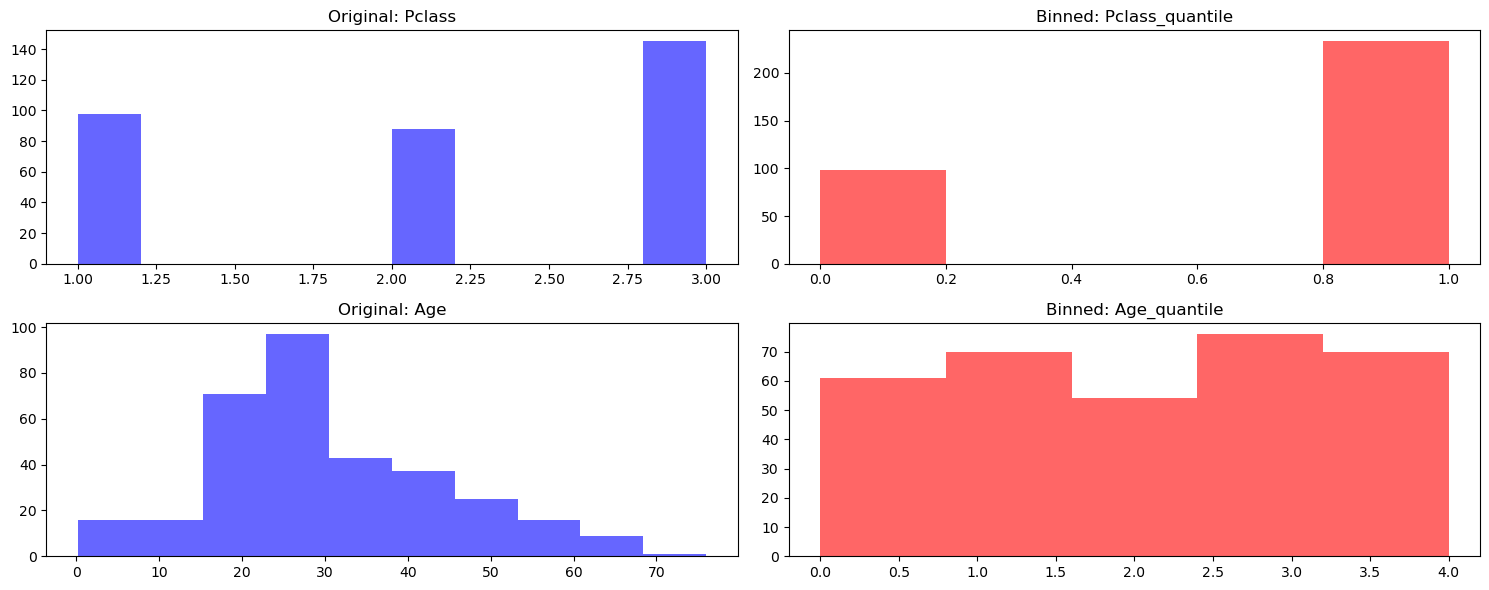

In [54]:
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
import matplotlib.pyplot as plt

# Read Titanic dataset (adjust the path as needed)
df = pd.read_csv(r'C:\Users\Cheru\OneDrive\Desktop\ML\Machine_learning\titanic\test.csv')

# Select numeric columns only (excluding 'PassengerId')
numeric = df.select_dtypes(include=['int64', 'float64']).dropna()

# Apply quantile-based binning (excluding 'PassengerId')
quantile_binner = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
quantile_binned = quantile_binner.fit_transform(numeric[['Pclass', 'Age']])

# Create DataFrame with new binned column names
quantile_binned_df = pd.DataFrame(quantile_binned, columns=['Pclass_quantile', 'Age_quantile'])
quantile_binned_df

# Create subplots (2 rows, number of columns based on numeric columns)
fig, axes = plt.subplots(len(numeric[['Pclass', 'Age']].columns), 2, figsize=(15, 6))

for i, col in enumerate(numeric[['Pclass', 'Age']].columns):
    # Plot original data (left column)
    axes[i, 0].hist(numeric[col], bins=10, color='blue', alpha=0.6)
    axes[i, 0].set_title(f"Original: {col}")

    # Plot binned data (right column)
    axes[i, 1].hist(quantile_binned_df[col + '_quantile'], bins=5, color='red', alpha=0.6)
    axes[i, 1].set_title(f"Binned: {col}_quantile")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


In [55]:
quantile_binned_df

,Pclass_quantile,Age_quantile
0,1.0,3.0
1,1.0,4.0
2,1.0,4.0
3,1.0,2.0
4,1.0,1.0
...,...,...
326,1.0,0.0
327,0.0,3.0
328,1.0,2.0
329,0.0,3.0


In [58]:
np.unique(quantile_binned_df.iloc[:,0:1],return_counts=True)

(array([0., 1.]), array([ 98, 233], dtype=int64))

In [59]:
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
df_Num = df.iloc[:,0:2].dropna()

,PassengerId,Pclass
0,892,3
1,893,3
2,894,2
3,895,3
4,896,3
...,...,...
413,1305,3
414,1306,1
415,1307,3
416,1308,3


In [74]:
df_Num = df.iloc[:,0:2].dropna()
KBinner = KBinsDiscretizer(n_bins=5,encode='ordinal', strategy="kmeans")
df_binned = pd.DataFrame(KBinner.fit_transform(df_Num), columns=df_Num.columns)
df_binned

c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\preprocessing\_discretization.py:239: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Cheru\anaconda3\ana\Lib\site-packages\sklearn\base.py:1151: ConvergenceWarning: Number of dist

,PassengerId,Pclass
0,0.0,2.0
1,0.0,2.0
2,0.0,1.0
3,0.0,2.0
4,0.0,2.0
...,...,...
413,4.0,2.0
414,4.0,0.0
415,4.0,2.0
416,4.0,2.0


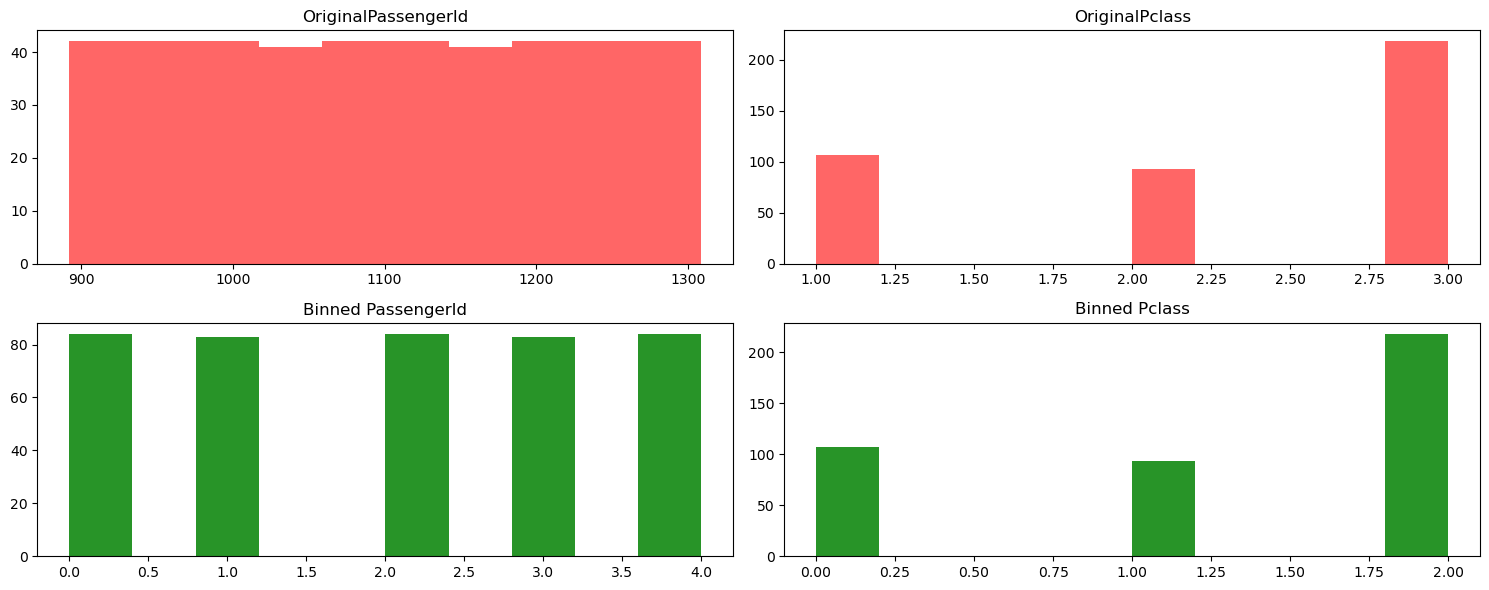

In [77]:
fig ,axes = plt.subplots(2,2 ,figsize =(15,6))
for i, col in enumerate(df_Num.columns):
    axes[0,i].hist(df_Num[col],alpha=0.6,bins =10,color = "red")
    axes[0,i].set_title(f"Original{col}")
    for i, col in enumerate(df_Num.columns):
      axes[1, i].hist(df_binned[col], alpha=0.6, bins=10, color="green")
      axes[1, i].set_title(f"Binned {col}")
plt.tight_layout()
plt.show()